# About Datasets
**I express my deep gratitude for the purity of the data of all the authors of the datasets. Of course, in some places the imbalance of classes is wild, but you can work with it**

* Personal Key Indicators of Heart Disease (PKIHD): https://www.kaggle.com/datasets/kamilpytlak/personal-key-indicators-of-heart-disease?datasetId=1936563&sortBy=voteCount&sort=published
* Heart Failure Prediction (HFCD): https://www.kaggle.com/datasets/andrewmvd/heart-failure-clinical-data
* Heart Failure Prediction Dataset (HFP): https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction

# ⚒ EDA Libraries

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import plotly
import plotly.graph_objs as go
import plotly.express as px
from plotly.subplots import make_subplots
import missingno as msno
import matplotlib.pyplot as plt

## ⚠️ EDA Constants

In [3]:
ROOT_DIR: Path = Path(__file__).parent.parent if "__file__" in locals() else Path.cwd().parent
DATASET_DIR: Path = ROOT_DIR / "data"
PKIHD: Path = DATASET_DIR / "PKIHD/heart_2020_cleaned.csv"
HFCD: Path = DATASET_DIR / "HFCD/heart_failure_clinical_records_dataset.csv"
DHD: Path = DATASET_DIR / "DHD/labels.csv"
METADATA: Path = DATASET_DIR / "DHD/metadata.csv"
HFP: Path = DATASET_DIR / "HFP/heart.csv"

# ⭐️ EDA 
* Primary data analysis
* Principal data analysis
* Foundation correlation and feature extraction

# Audio samples

In [4]:
metadata = pd.read_csv(METADATA)
metadata.head(5)

,sample_rate,num_frames,num_channels,bits_per_sample,encoding,duration,filename
0,44100,396900,1,16,PCM_S,9.0,artifact__201012172012.wav
1,44100,396900,1,16,PCM_S,9.0,artifact__201105040918.wav
2,44100,396900,1,16,PCM_S,9.0,artifact__201105041959.wav
3,44100,396900,1,16,PCM_S,9.0,artifact__201105051017.wav
4,44100,396900,1,16,PCM_S,9.0,artifact__201105060108.wav


In [8]:
metadata.duration.describe()

count    661.000000
mean       9.066551
std       13.263770
min        0.760000
25%        3.620000
50%        7.390000
75%        9.770000
max      210.000000
Name: duration, dtype: float64

In [4]:
LABELS = pd.read_csv(DHD)
LABELS.head(5)

,set,filename,label
0,A,artifact__201012172012.wav,artifact
1,A,artifact__201105040918.wav,artifact
2,A,artifact__201105041959.wav,artifact
3,A,artifact__201105051017.wav,artifact
4,A,artifact__201105060108.wav,artifact


In [5]:
LABELS.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 661 entries, 0 to 660
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   set       661 non-null    object
 1   filename  661 non-null    object
 2   label     661 non-null    object
dtypes: object(3)
memory usage: 15.6+ KB


In [17]:
labels_count = LABELS["label"].value_counts()
labels_count

label
normal        355
murmur        149
artifact       92
extrastole     46
extrahls       19
Name: count, dtype: int64

In [26]:
px.pie(values=labels_count.values, names=list(labels_count.index.values))

In [29]:
unite_abnormal = lambda x: "abnormal" if x in ["murmur", 'extrastole', 'extrahls'] else x
united_value_counts = LABELS.label.apply(unite_abnormal).value_counts()
united_value_counts

label
normal      355
abnormal    214
artifact     92
Name: count, dtype: int64

In [30]:
px.pie(values=united_value_counts.values, names=list(united_value_counts.index.values))

# Tabular

In [12]:
PKIHD_DF = pd.read_csv(PKIHD)
PKIHD_DF.head()

,BMI,PhysicalHealth,MentalHealth,SleepTime
count,319795.000000,319795.00000,319795.000000,319795.000000
mean,28.325399,3.37171,3.898366,7.097075
std,6.356100,7.95085,7.955235,1.436007
min,12.020000,0.00000,0.000000,1.000000
25%,24.030000,0.00000,0.000000,6.000000
50%,27.340000,0.00000,0.000000,7.000000
75%,31.420000,2.00000,3.000000,8.000000
max,94.850000,30.00000,30.000000,24.000000


In [17]:
HFCD_DF = pd.read_csv(HFCD)
HFCD_DF.head()

,BMI,PhysicalHealth,MentalHealth,SleepTime
count,319795.000000,319795.00000,319795.000000,319795.000000
mean,28.325399,3.37171,3.898366,7.097075
std,6.356100,7.95085,7.955235,1.436007
min,12.020000,0.00000,0.000000,1.000000
25%,24.030000,0.00000,0.000000,6.000000
50%,27.340000,0.00000,0.000000,7.000000
75%,31.420000,2.00000,3.000000,8.000000
max,94.850000,30.00000,30.000000,24.000000


## Column overview

In [5]:
PKIHD_DF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  object 
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  object 
 3   AlcoholDrinking   319795 non-null  object 
 4   Stroke            319795 non-null  object 
 5   PhysicalHealth    319795 non-null  float64
 6   MentalHealth      319795 non-null  float64
 7   DiffWalking       319795 non-null  object 
 8   Sex               319795 non-null  object 
 9   AgeCategory       319795 non-null  object 
 10  Race              319795 non-null  object 
 11  Diabetic          319795 non-null  object 
 12  PhysicalActivity  319795 non-null  object 
 13  GenHealth         319795 non-null  object 
 14  SleepTime         319795 non-null  float64
 15  Asthma            319795 non-null  object 
 16  KidneyDisease     31

In [6]:
HFCD_DF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


## Check null

In [10]:
print(
    f"""
    PKIHD:\n{PKIHD_DF.isna().sum()}
    \nHFCD_DF:\n{HFCD_DF.isna().sum()}
    """
)


    PKIHD:
HeartDisease        0
BMI                 0
Smoking             0
AlcoholDrinking     0
Stroke              0
PhysicalHealth      0
MentalHealth        0
DiffWalking         0
Sex                 0
AgeCategory         0
Race                0
Diabetic            0
PhysicalActivity    0
GenHealth           0
SleepTime           0
Asthma              0
KidneyDisease       0
SkinCancer          0
dtype: int64
    
HFP_DF:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64
    
HFCD_DF:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0

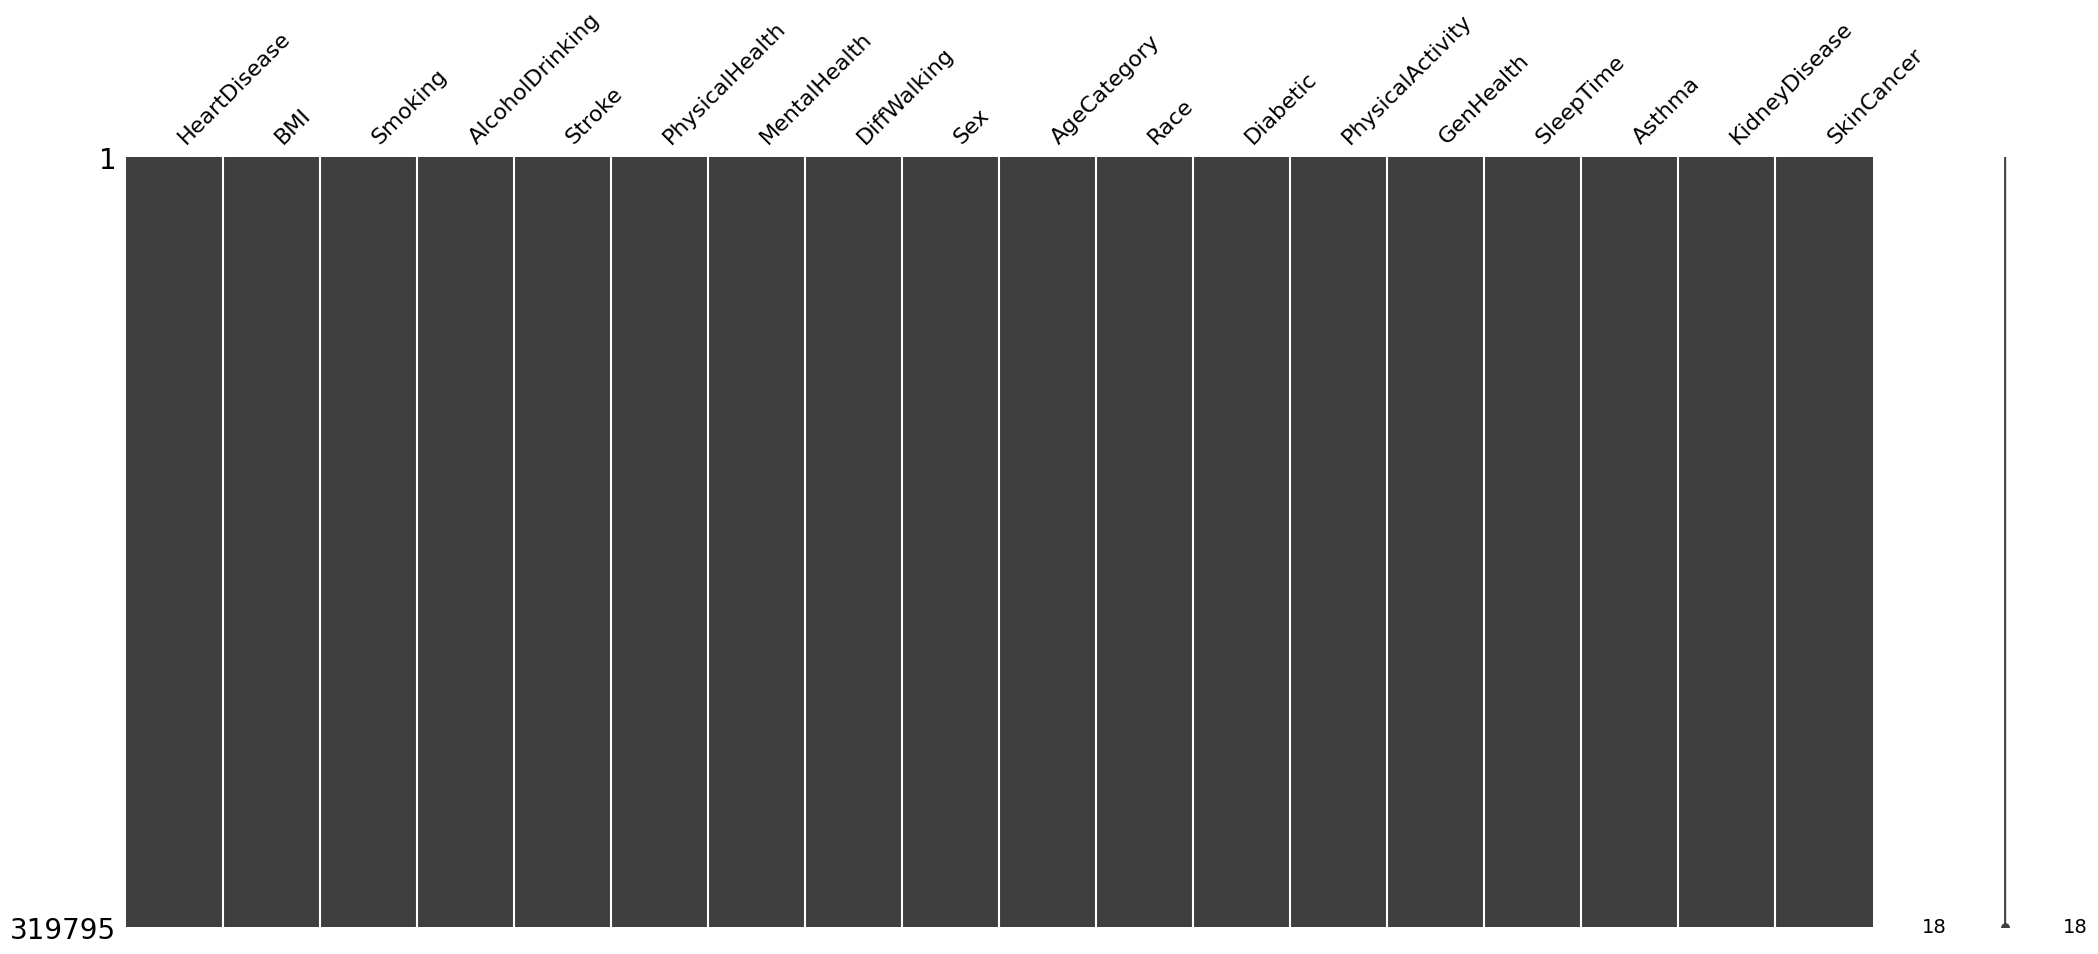

In [11]:
msno.matrix(PKIHD_DF)
plt.show()

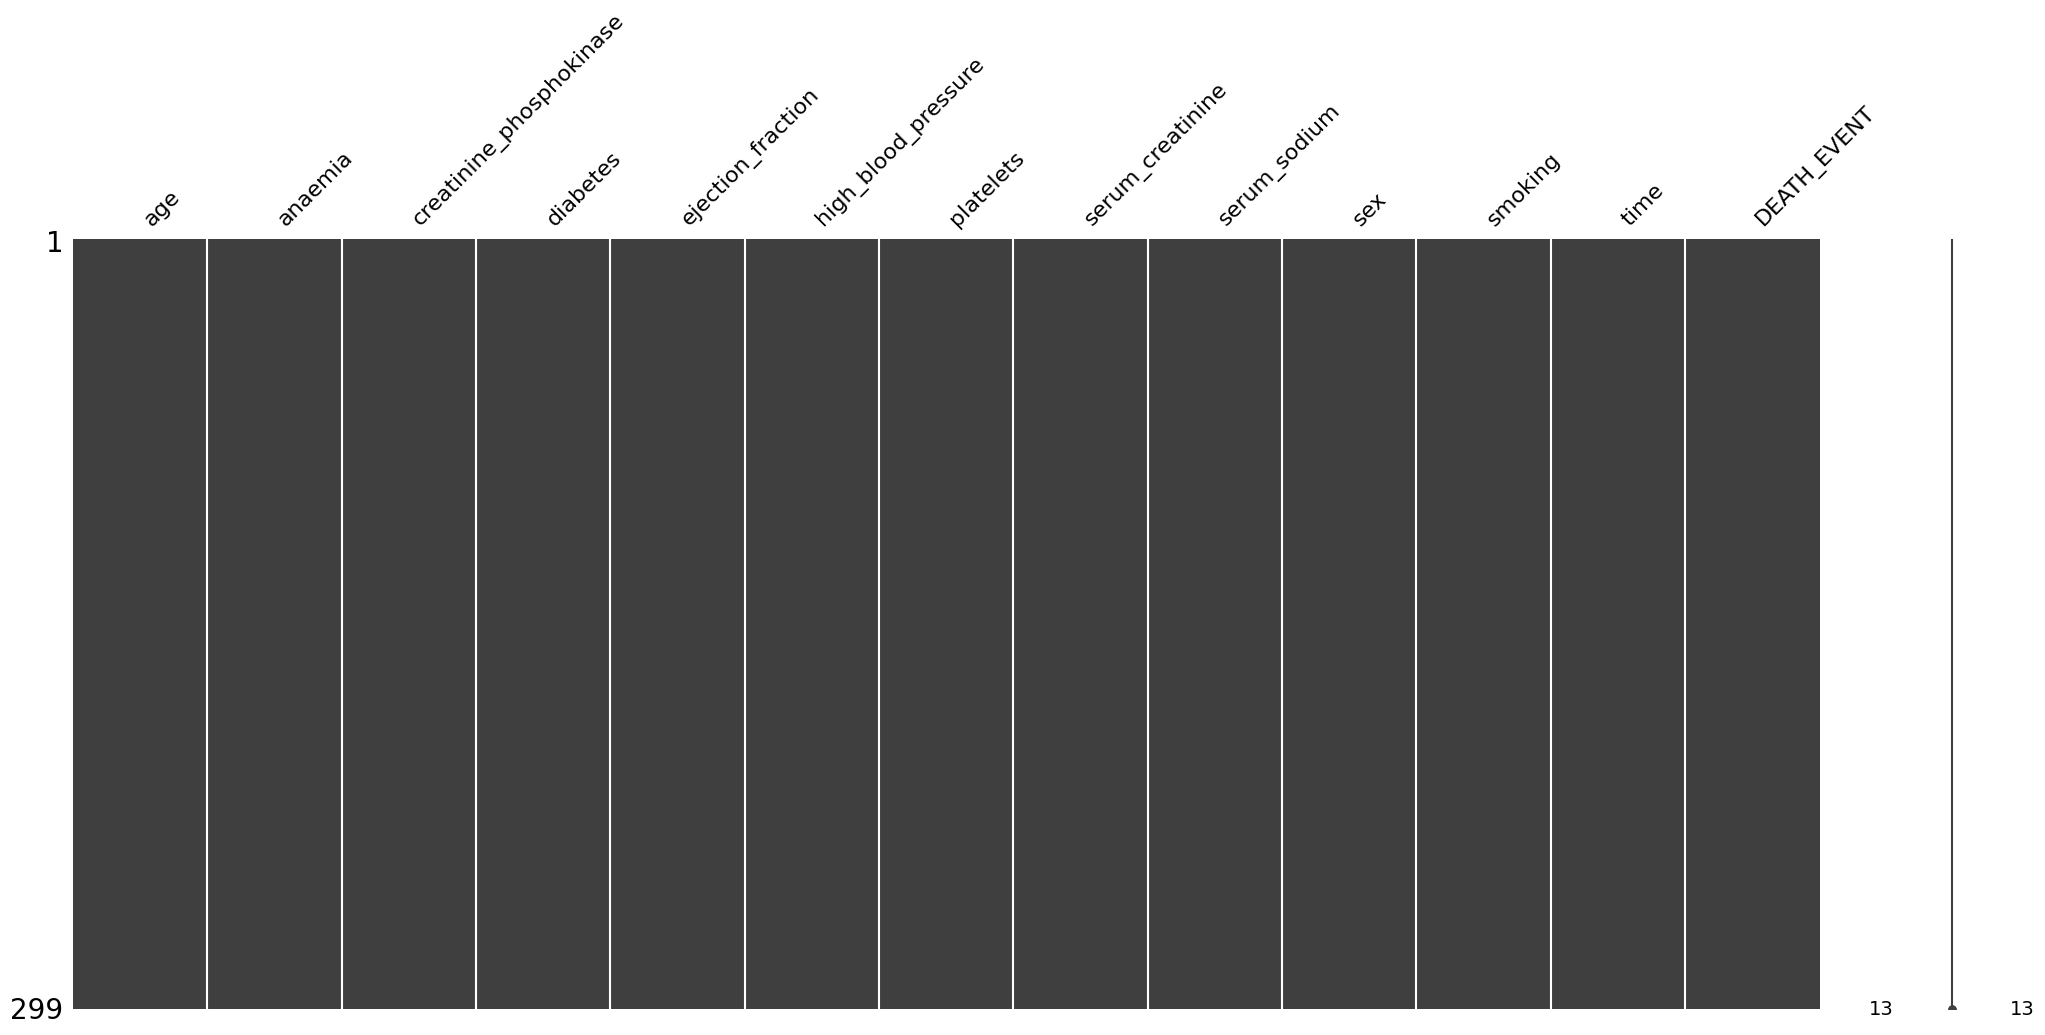

In [13]:
msno.matrix(HFCD_DF)
plt.show()

## Column naming

In [7]:
HFCD_DF = HFCD_DF.replace(
    {
        "smoking": {0: "No", 1: "Yes"},
        "high_blood_pressure": {0: "negative", 1: "positive"},
        "sex": {0: "female", 1: "male"},
        "anaemia": {0: "negative", 1: "positive"},
        "diabetes": {0: "negative", 1: "positive"}, 
        "DEATH_EVENT": {0: "alive", 1: "dead"}
    },
).sort_values(by="age")

In [69]:
px.bar(HFCD_DF, x="high_blood_pressure", color="DEATH_EVENT")

In [41]:
px.pie(df, names="HeartDisease")

In [42]:
px.pie(df, names="Sex") 

In [62]:
px.pie(df, names="diabetes") 

In [80]:
[col for col, dtype in HFCD_DF.dtypes.items() if dtype in ["int64"]]
    

['creatinine_phosphokinase', 'ejection_fraction', 'serum_sodium', 'time']

In [58]:
HFCD_DF.dtypes.where(HFCD_DF.dtypes in ["int64", "float64"])

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

## Quantitative indicators of the sample

In [34]:
fig = make_subplots(
    rows=3, 
    cols=2,
    specs=[
        [
            {"type": "pie"}, 
            {"type": "pie"}
        ],
        [
            {"type": "pie"},
            {"type": "pie"},
        ],
        [
            {"type": "pie"},
            {"type": "pie"},
        ]
    ]
).update_layout(go.Layout(title="Quantitative indicators of the sample"))


fig.add_trace(
    go.Pie(
    values=HFCD_DF["DEATH_EVENT"].value_counts(),  
    labels=["survived", "died"],
    hole=0.4,
    name="HFCD: survival",  
    ),
    col=1,
    row=1,
)

fig.add_trace(
    go.Pie(
    values=HFCD_DF["sex"].value_counts(),  
    labels=["male", "female"],
    hole=0.4,
    name="HFCD: sex"    
    ),
    col=2,
    row=1
)


fig.add_trace(
    go.Pie(
    values=PKIHD_DF["HeartDisease"].value_counts(),  
    labels=["survived", "died"],
    hole=0.4,
    name="PKIHD: survival",  
    ),
    col=1,
    row=2,
)

fig.add_trace(
    go.Pie(
    values=PKIHD_DF["Sex"].value_counts(),  
    labels=["male", "female"],
    hole=0.4,
    name="PKIHD: sex"    
    ),
    col=2,
    row=2
)

fig.show()

# Datasets overview
****

In [13]:
fig = px.bar(     
    HFCD_DF,
    x="sex",  
    color="DEATH_EVENT"
)

fig.show()

In [20]:
fig = px.bar(     
    HFCD_DF,
    x="sex", y="serum_sodium", # color="smoking"
)

fig

## Distribution: age

In [ ]:
px.histogram(HFCD_DF, x="age", title="Distribution: age")

## Distribution: creatinine_phosphokinase

In [15]:
px.histogram(dataset_df, x="creatinine_phosphokinase", title="Distribution: creatinine_phosphokinase")

## Distribution: ejection_fraction

In [16]:
px.histogram(dataset_df, x="ejection_fraction", title="Distribution: ejection_fraction")

## Distribution: platelets

In [17]:
px.histogram(dataset_df, x="platelets", title="Distribution: platelets")

## Serum Creatinine

## Distibution

In [76]:
px.histogram(dataset_df, x="serum_creatinine", title="Distribution")